In [1]:
def seasonality_index_walsh_lawler(rainfall):
    """
    rainfall: DataArray (time, lat, lon) with monthly data
    returns: SI (lat, lon)
    """

    # Monthly climatology
    monthly_clim = rainfall.groupby('time.month').mean('time')

    # Annual total
    annual_total = monthly_clim.sum('month')

    # Mean monthly rainfall
    mean_monthly = annual_total / 12

    # Walsh & Lawler SI
    si = (abs(monthly_clim - mean_monthly)
          .sum('month')) / annual_total

    si.name = 'Seasonality Index'
    si.attrs['description'] = 'Walsh and Lawler (1981) Seasonality Index'

    return si

In [15]:
import colormaps as cmaps 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
%config InlineBackend.figure_format = 'retina'
import xarray as xr
import geopandas as gpd
import numpy as np

In [11]:
climo = xr.open_mfdataset('v2p0chirps_mo_25.nc',decode_times=False)['precip'].mean('time')

In [6]:
precip_coordex = xr.open_mfdataset('Precip/*.nc').sel(rlon=slice(-4,2), rlat=slice(4,12))['pr'].load()

/Users/ktquagra/miniconda3/envs/homepy/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Users/ktquagra/miniconda3/envs/homepy/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Users/ktquagra/miniconda3/envs/homepy/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Users/ktquagra/miniconda3/envs/homepy/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Users/ktquagra/miniconda3/envs/homepy/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/Users/ktquagra/miniconda3/envs/homepy/lib/python3.13/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid

In [7]:
precip_chirps = xr.open_mfdataset('v2p0chirps_mo_25.nc', decode_times=False).sel(longitude=slice(-4,2), latitude=slice(4,12)).rename(
    {'longitude':'rlon', 'latitude':'rlat'})
reference_date = '1981-01-15'
precip_chirps['time'] = pd.date_range(start=reference_date, periods=precip_chirps.sizes['time'], freq='MS')

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 543, rlon: 24, rlat: 32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-02-01 1981-03-01 ... 2026-04-01
  * rlon     (rlon) float32 96B -3.875 -3.625 -3.375 ... 1.375 1.625 1.875
  * rlat     (rlat) float32 128B 4.125 4.375 4.625 4.875 ... 11.38 11.62 11.88
Data variables:
    precip   (time, rlat, rlon) float32 2MB dask.array<chunksize=(1, 32, 24), meta=np.ndarray>
Attributes: (12/30)
    CDI:                        Climate Data Interface version 2.5.3 (https:/...
    Conventions:                CF-1.6
    institution:                Climate Hazards Group.  University of Califor...
    title:                      CHIRPS Version 2.0
    version:                    Version 2.0
    date_created:               2015-10-07
    ...                         ...
    time_coverage_end:          2026-03-31
    frequency:                  mon
    CDO:                        Climate Data Operators version 2.5.3 (https:/...
    history:                    Tue Apr 14 08:26:14 2026: ncatted -a units,pr...
    NCO:                        netCDF Operators version 5.3.3 (Homepage = ht...
    climexp_url:                https://climexp.knmi.nl/select.cgi?chirps_20_...

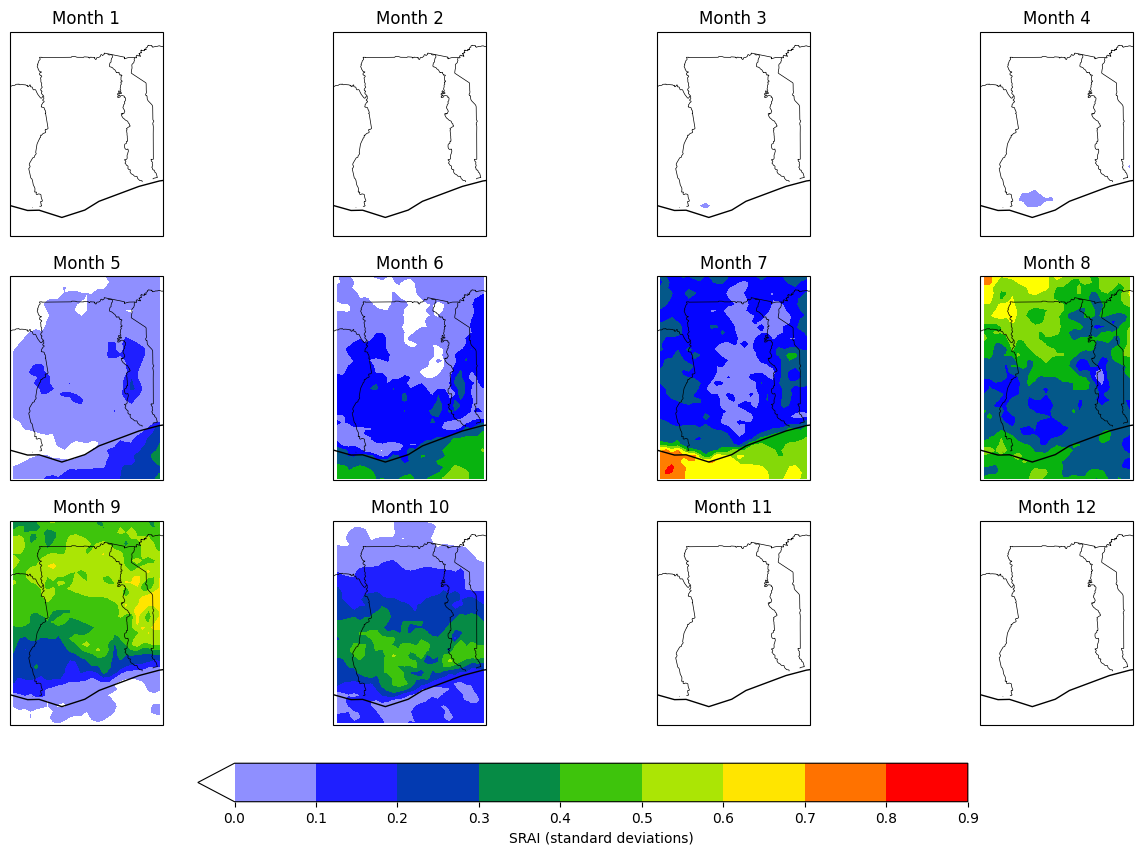

In [100]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Compute SRAI
srai = standardized_rainfall_anomaly_index(
    precip_coordex, 
    # reference_period=(1981, 2010)
)

# Monthly mean
srai_monthly = srai.groupby('time.month').mean('time')

# Create subplots
fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for i, month in enumerate(srai_monthly.month.values):
    ax = axes[i]

    im = srai_monthly.sel(month=month).plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmaps.wh_bl_gr_ye_re,
        vmin=0,
        vmax=1,
        levels=np.arange(0,1,0.1),
        add_colorbar=False
    )

    # Map features
    ax.coastlines(resolution='110m')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(f'Month {month}')

    # Optional: focus on West Africa
    ax.set_extent([-4, 2, 4, 12], crs=ccrs.PlateCarree())

# Shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    fraction=0.05,
    pad=0.05
)
cbar.set_label('SRAI (standard deviations)')

# plt.tight_layout()
plt.show()

In [8]:
mon_ds = precip_coordex.resample(time='1m').sum('time')

/Users/ktquagra/miniconda3/envs/homepy/lib/python3.13/site-packages/xarray/groupers.py:498: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [9]:
si_coordex = seasonality_index_walsh_lawler(mon_ds)
si_chirps= seasonality_index_walsh_lawler(precip_chirps['precip'])

In [10]:
##### Functoin to Draw a zebra border around maps ############
import itertools
import matplotlib.patheffects as pe

crs = ccrs.PlateCarree()
def add_zebra_frame(ax, lw=4, crs="pcarree", zorder=None):

    ax.spines["geo"].set_visible(False)
    left, right, bot, top = ax.get_extent()

    sub = 2
    # Alternate black and white line segments
    bws = itertools.cycle(["k", "white"])

    xticks = sorted([left, *ax.get_xticks(), right])
    xticks = np.unique(np.array(xticks))
    yticks = sorted([bot, *ax.get_yticks(), top])
    yticks = np.unique(np.array(yticks))
    for ticks, which in zip([xticks, yticks], ["lon", "lat"]):
        for idx, (start, end) in enumerate(zip(ticks, ticks[1:])):
            bw = next(bws)
            if which == "lon":
                xs = [[start, end], [start, end]]
                ys = [[bot, bot], [top, top]]
            else:
                xs = [[left, left], [right, right]]
                ys = [[start, end], [start, end]]

            # For first and lastlines, used the "projecting" effect
            capstyle = "butt" if idx not in (0, len(ticks) - 2) else "projecting"
            for (xx, yy) in zip(xs, ys):
                ax.plot(
                    xx,
                    yy,
                    color=bw,
                    linewidth=lw,
                    clip_on=False,
                    transform=crs,
                    zorder=zorder,
                    solid_capstyle=capstyle,
                    # Add a black border to accentuate white segments
                    path_effects=[
                        pe.Stroke(linewidth=lw + 1, foreground="black"),
                        pe.Normal(),
                    ],
                )

/var/folders/46/zk0gb72s2yz3w1h6j78jbg5w0000gn/T/ipykernel_11666/1594274582.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


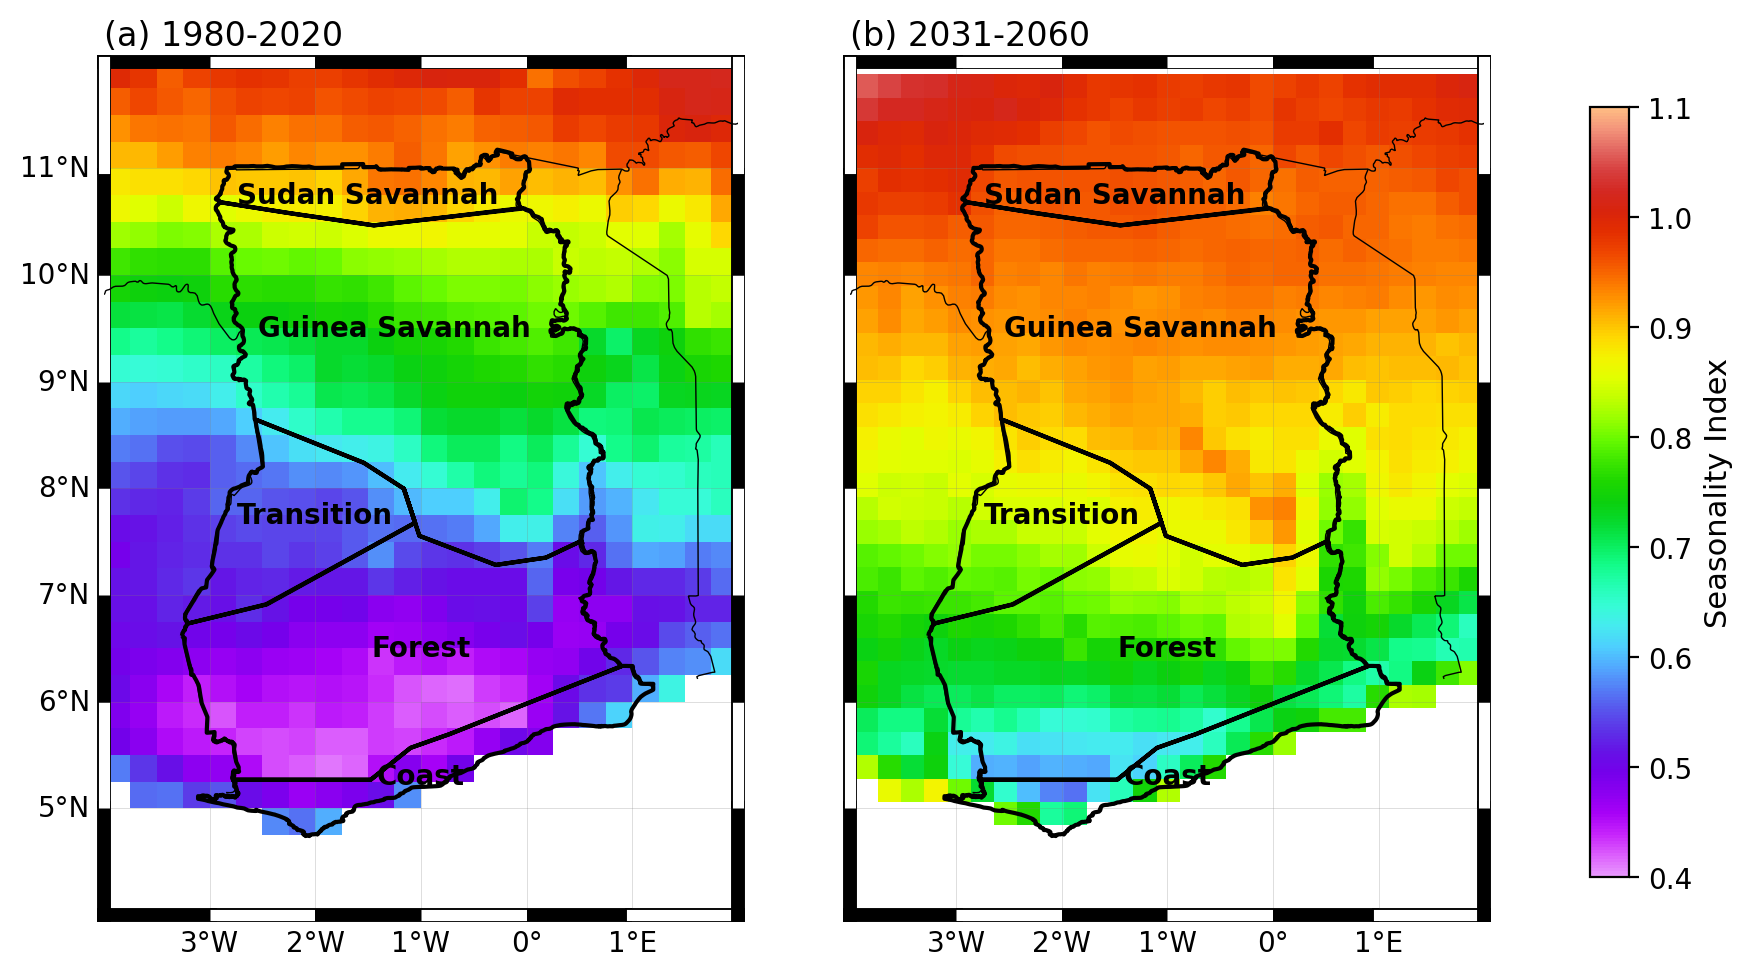

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# --- Read shapefile ---
shp = gpd.read_file("Ghana_ACZ_Shapefiles/gha_admbnda_adm0_gss_20210308.shx")

# --- (Optional) ensure WGS84 for Cartopy compatibility ---
shp = shp.to_crs(epsg=4326)


lons_tx = [-1, -1, -2, -1.25, -1.5]
lats_tx = [5.3, 6.5, 7.75, 9.5, 10.75]
texts = ['Coast', 'Forest', 'Transition', "Guinea Savannah", "Sudan Savannah"]

# Create mask
mask = si_chirps.notnull()

# Convert to numeric (required for interpolation)
mask_float = mask.astype(float)

# Interpolate to CORDEX grid
mask_interp = mask_float.interp_like(si_coordex)

# Convert back to boolean mask
mask_final = mask_interp > 0.5

# Apply mask
si_coordex_masked = si_coordex.where(mask_final)

# --- Plot ---
fig, axes = plt.subplots(
    figsize=(12, 5),
    sharex=True, sharey=True,
    ncols=2, nrows=1,
    subplot_kw={'projection': ccrs.PlateCarree()}
)

datasets = [si_chirps, si_coordex_masked]
titles = ['(a) 1980-2020', '(b) 2031-2060']

for i, (ax, dd, title) in enumerate(zip(axes, datasets, titles)):

    dd = dd.sel(rlon = slice(-4,2), rlat=slice(4.5,12))
    im = dd.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmaps.NCV_bright,
        vmin=0.4,
        vmax=1.1,
        add_colorbar=False
    )

    # ax.coastlines(resolution='110m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=5,)

    ax.set_extent([-4, 2, 4, 12], crs=ccrs.PlateCarree())
    # ax.set_extent([minx - x_margin, maxx + x_margin, miny - y_margin, maxy + y_margin], crs=ccrs.PlateCarree())

    gl=ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
               crs=ccrs.PlateCarree(), linewidth=0.3, color='gray', alpha=0.3)
    # gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False

    # cleaner labeling: only left plot has y labels
    if i == 1:
        gl.left_labels = False

    ax.set_title(title, fontsize=12, loc='left')
    shp.boundary.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        facecolor="none",   # outline only
        edgecolor="black",zorder=2,
        linewidth=1.5
    )
    add_zebra_frame(ax,crs=ccrs.PlateCarree())
    # Get bounds of Ghana shapefile for dynamic centering
    minx, miny, maxx, maxy = shp.total_bounds
    
    # Add margin around the bounds (10% margin)
    x_margin = (maxx - minx) * 0.05
    y_margin = (maxy - miny) * 0.05

    # Add text annotations
    for lon, lat, txt in zip(lons_tx, lats_tx, texts):
        ax.text(
            lon, lat, txt,
            transform=ccrs.PlateCarree(),  # IMPORTANT
            fontsize=10,
            ha='center',
            va='center',
            fontweight='bold',
            bbox=dict(facecolor='none', alpha=0.6, edgecolor='none', pad=1)
        )
    
# Shared colorbar (fixed placement)
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='vertical',
    fraction=0.04,
    pad=-0.25
)

plt.tight_layout()
cbar.set_label('Seasonality Index', fontsize=11)
plt.savefig('SI_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

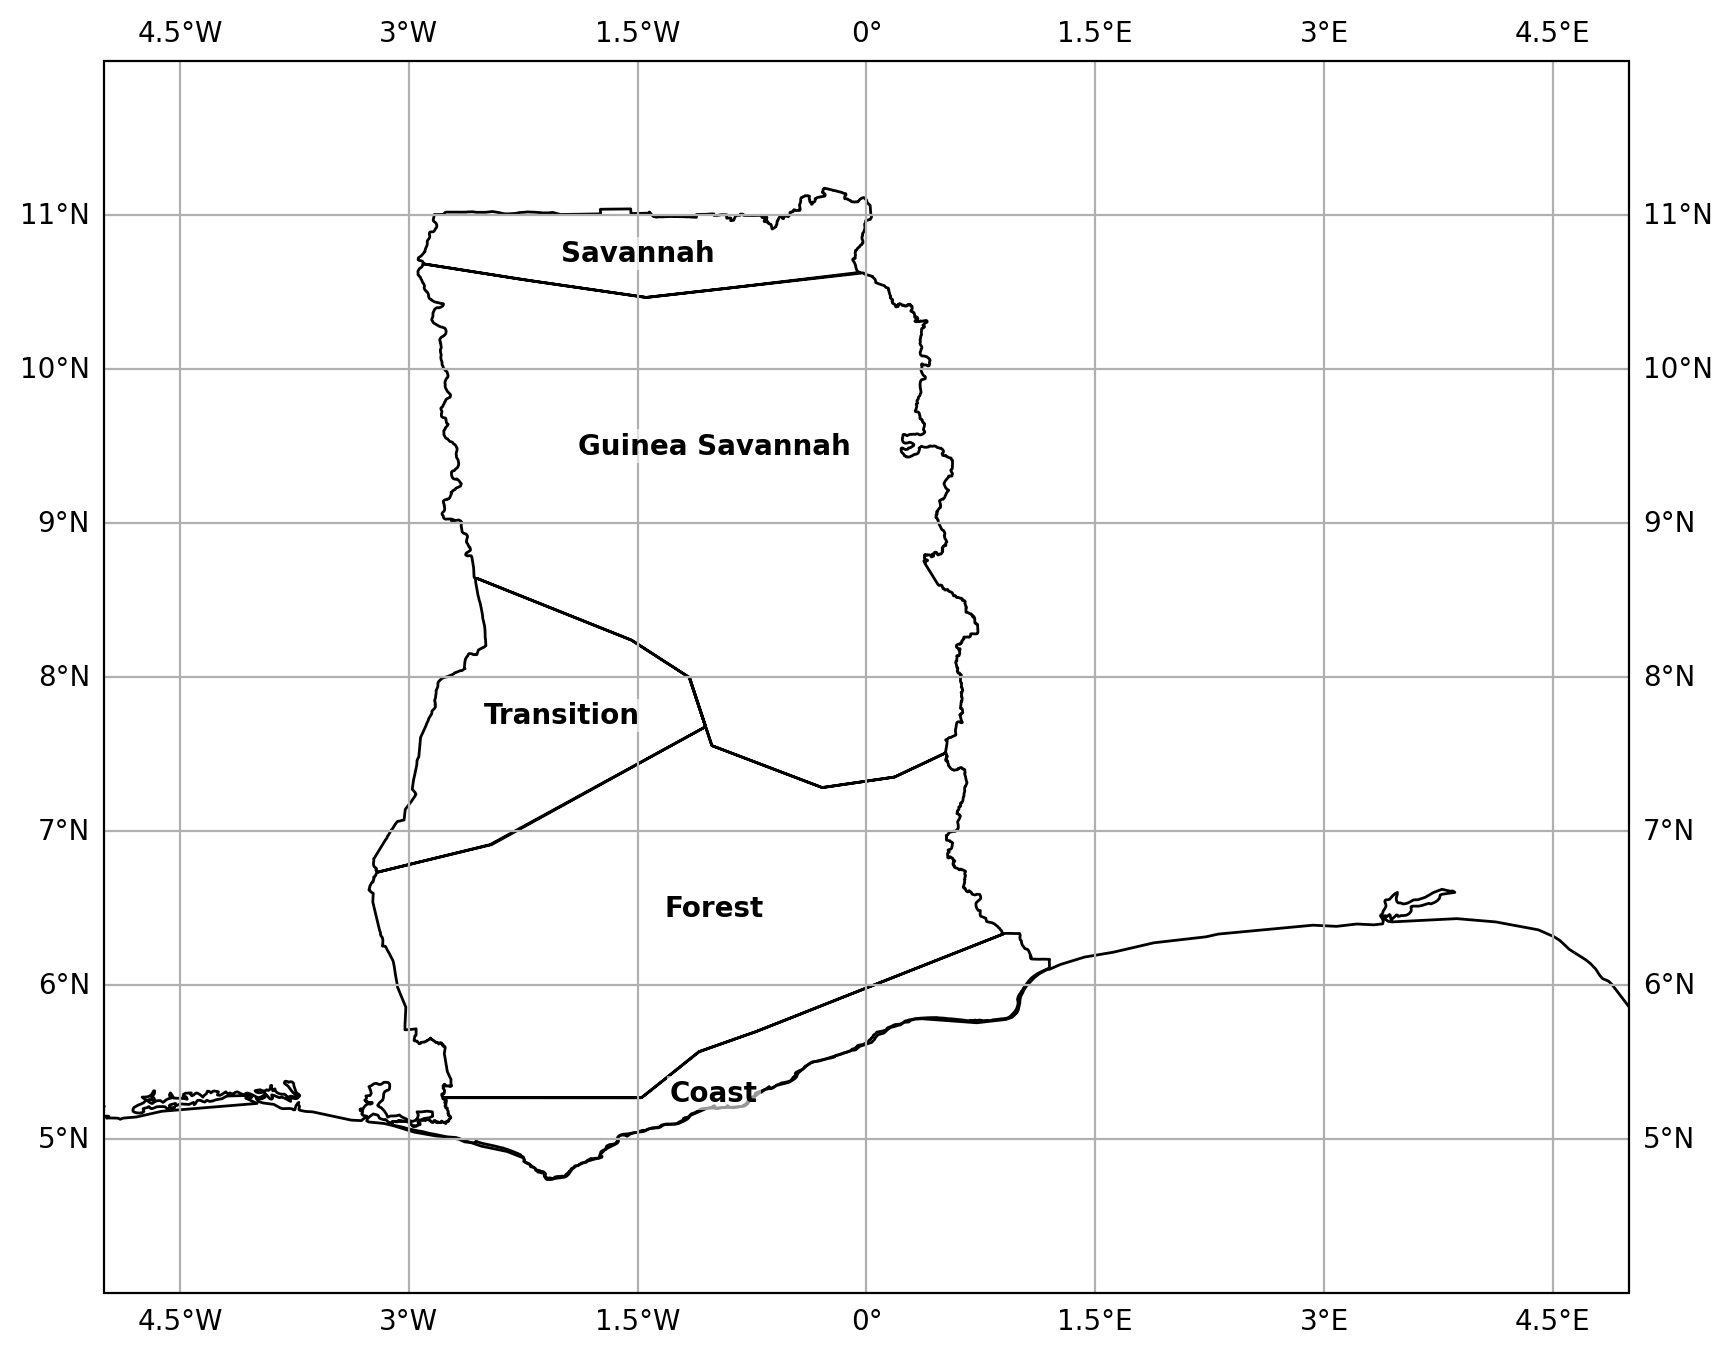

In [231]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Read shapefile ---
shp_or = gpd.read_file("Ghana_ACZ_Shapefiles/gha_admbnda_adm0_gss_20210308.shp")

# --- (Optional) ensure WGS84 for Cartopy compatibility ---
shp = shp.to_crs(epsg=4326)
lons_tx = [-1, -1, -2, -1, -1.5]
lats_tx = [5.3, 6.5, 7.75, 9.5, 10.75]
texts = ['Coast', 'Forest', 'Transition', "Guinea Savannah", "Savannah"]

# --- Create map ---
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent (modify as needed)
ax.set_extent([-5, 5, 4, 12], crs=ccrs.PlateCarree())

# --- Plot shapefile ---
shp.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    facecolor="none",   # outline only
    edgecolor="black",
    linewidth=1
)
# Add text annotations
for lon, lat, txt in zip(lons_tx, lats_tx, texts):
    ax.text(
        lon, lat, txt,
        transform=ccrs.PlateCarree(),  # IMPORTANT
        fontsize=10,
        ha='center',
        va='center',
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
    )

# --- Add features (optional) ---
ax.coastlines()
ax.gridlines(draw_labels=True)

plt.show()

In [24]:
precip_chirps_2 = xr.open_dataset('v2p0chirps_25.nc').sel(longitude=slice(-20,55),latitude=slice(0,30)).load()

In [80]:
import xarray as xr
import numpy as np

def standardized_rainfall_anomaly(ds, var_name="RR"):
    """
    Compute the Standardized Rainfall Anomaly (SRA)
    for an xarray Dataset/DataArray with dimensions:
    time, lat, lon.

    Parameters
    ----------
    ds : xarray.Dataset or xarray.DataArray
        Input rainfall dataset containing a time dimension.
        
    var_name : str, optional
        Name of the rainfall variable if ds is a Dataset.
        Default is "RR".

    Returns
    -------
    sra : xarray.DataArray
        Standardized rainfall anomaly with dimensions:
        time, lat, lon.
    """

    # ---------------------------------------------------------
    # Extract rainfall variable
    # ---------------------------------------------------------
    if isinstance(ds, xr.Dataset):
        rain = ds[var_name]
    else:
        rain = ds

    rain = rain.resample(time='1ME').sum('time')
    # ---------------------------------------------------------
    # Compute monthly climatology
    # (mean rainfall for each calendar month)
    # ---------------------------------------------------------
    monthly_mean = rain.groupby("time.month").mean(dim="time")

    # ---------------------------------------------------------
    # Compute monthly standard deviation
    # ---------------------------------------------------------
    monthly_std = rain.groupby("time.month").std(dim="time")

    # ---------------------------------------------------------
    # Compute rainfall anomaly:
    # rainfall - monthly climatological mean
    # ---------------------------------------------------------
    anomaly = rain.groupby("time.month") - monthly_mean

    # ---------------------------------------------------------
    # Standardize anomaly:
    # anomaly / monthly standard deviation
    # ---------------------------------------------------------
    sra = anomaly.groupby("time.month") / monthly_std

    # ---------------------------------------------------------
    # Add metadata
    # ---------------------------------------------------------
    sra.name = "Standardized_Rainfall_Anomaly"
    sra.attrs["long_name"] = "Standardized Rainfall Anomaly"
    sra.attrs["description"] = (
        "Monthly rainfall anomalies standardized by "
        "monthly climatological standard deviation"
    )

    return sra

In [81]:
sra_calc = standardized_rainfall_anomaly(precip_chirps_2,'precip')

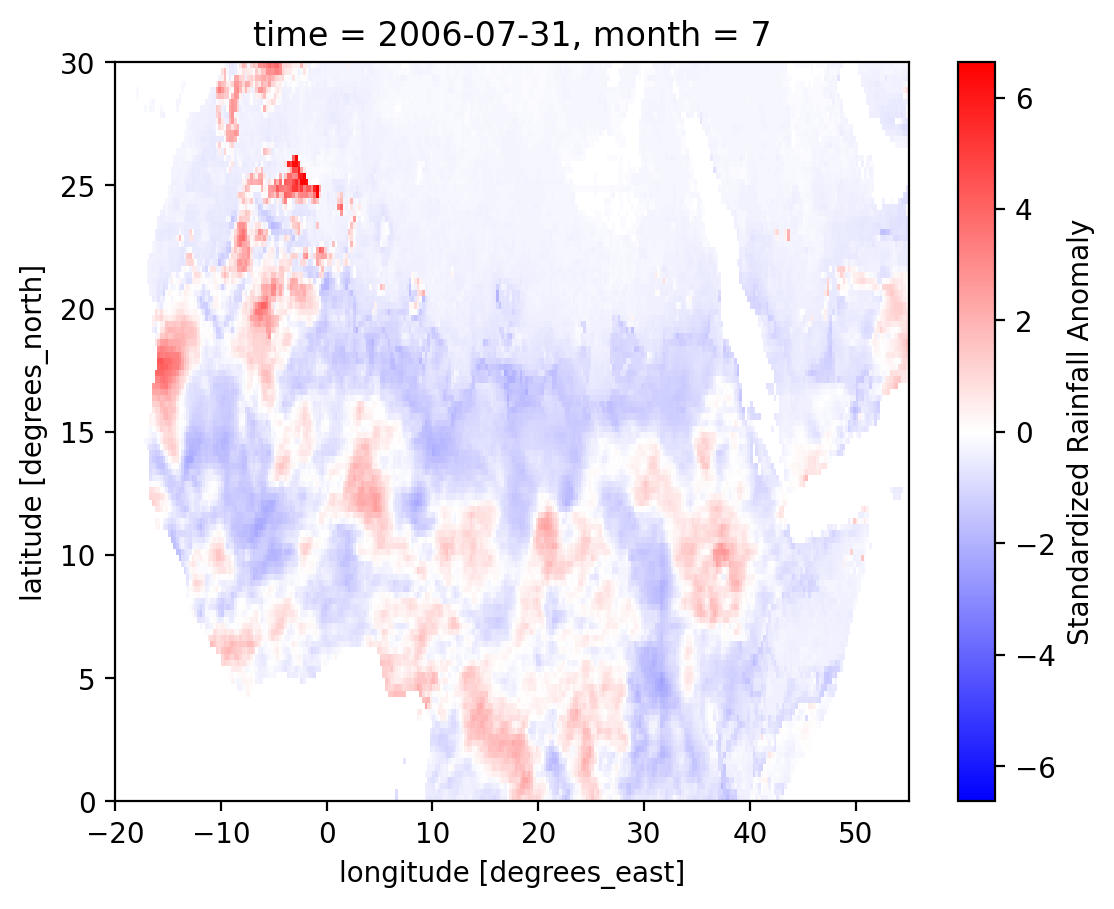

In [85]:
sra_calc[306].plot(cmap='bwr')

In [95]:
import numpy as np
import pandas as pd
import xarray as xr


def rainfall_seasonality_analysis(
    ds,
    var_name="precip",
    window=28,
):
    """
    Detect rainfall onset, cessation, and season length
    using cumulative rainfall anomaly analysis.

    Parameters
    ----------
    ds : xarray.Dataset or xarray.DataArray
        Daily rainfall dataset with dimensions:
        time, lat, lon

    var_name : str
        Rainfall variable name if ds is Dataset

    window : int
        Sliding window size used for onset/cessation detection

    Returns
    -------
    results : xarray.Dataset
        Dataset containing:
        - climatological_daily_mean
        - climatological_annual_mean
        - anomaly
        - SRAI
        - cumulative_anomaly
        - onset_day
        - cessation_day
        - season_length
    """

    # ---------------------------------------------------------
    # Extract rainfall DataArray
    # ---------------------------------------------------------
    if isinstance(ds, xr.Dataset):
        rain = ds[var_name]
    else:
        rain = ds

    # ---------------------------------------------------------
    # Remove leap day for consistency (optional)
    # ---------------------------------------------------------
    rain = rain.sel(
        time=~((rain.time.dt.month == 2) &
               (rain.time.dt.day == 29))
    )

    # ---------------------------------------------------------
    # Create Julian day coordinate
    # ---------------------------------------------------------
    rain.coords["doy"] = rain.time.dt.dayofyear

    # ---------------------------------------------------------
    # 1. Daily climatological mean
    # Mean rainfall for each Julian day
    # ---------------------------------------------------------
    clim_daily = rain.groupby("doy").mean("time")

    # ---------------------------------------------------------
    # 2. Climatological annual mean
    # Mean rainfall across all days
    # ---------------------------------------------------------
    clim_annual = clim_daily.mean("doy")

    # ---------------------------------------------------------
    # 3. Temporal anomalies
    # x_i - annual climatological mean
    # ---------------------------------------------------------
    anomaly = clim_daily - clim_annual

    # ---------------------------------------------------------
    # 4. Standardized Rainfall Anomaly Index (SRAI)
    # ---------------------------------------------------------
    clim_std = clim_daily.std("doy")

    srai = (clim_daily - clim_annual) / clim_std

    srai.name = "SRAI"

    # ---------------------------------------------------------
    # 5. Cumulative anomaly curve
    # ---------------------------------------------------------
    cumulative_anomaly = anomaly.cumsum(dim="doy")

    # ---------------------------------------------------------
    # Helper function for onset/cessation detection
    # ---------------------------------------------------------
    def detect_onset_cessation(arr, window=28):

        arr = np.asarray(arr)

        n = len(arr)

        # Initialize arrays
        rolling_min = np.full(n, np.nan)
        rolling_max = np.full(n, np.nan)

        # Sliding window analysis
        for i in range(n - window):

            subset = arr[i:i + window]

            rolling_min[i] = np.min(subset)
            rolling_max[i] = np.max(subset)

        # Onset = location of minimum cumulative anomaly
        onset = np.nanargmin(rolling_min) + 1

        # Cessation = location of maximum cumulative anomaly
        cessation = np.nanargmax(rolling_max) + 1

        # Season length
        length = cessation - onset + 1

        return onset, cessation, length

    # ---------------------------------------------------------
    # Apply function across lat/lon grid
    # ---------------------------------------------------------
    onset, cessation, length = xr.apply_ufunc(
        detect_onset_cessation,
        cumulative_anomaly,
        kwargs={"window": window},
        input_core_dims=[["doy"]],
        output_core_dims=[[], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[int, int, int],
    )

    # ---------------------------------------------------------
    # Create output dataset
    # ---------------------------------------------------------
    results = xr.Dataset({

        "climatological_daily_mean": clim_daily,

        "climatological_annual_mean": clim_annual,

        "anomaly": anomaly,

        "SRAI": srai,

        "cumulative_anomaly": cumulative_anomaly,

        "onset_day": onset,

        "cessation_day": cessation,

        "season_length": length,
    })

    # ---------------------------------------------------------
    # Add metadata
    # ---------------------------------------------------------
    results["onset_day"].attrs["description"] = \
        "Detected onset Julian day"

    results["cessation_day"].attrs["description"] = \
        "Detected cessation Julian day"

    results["season_length"].attrs["description"] = \
        "Rainy season duration in days"

    return results

In [97]:
# Run analysis
results = rainfall_seasonality_analysis(
    precip_chirps_2,
    var_name="precip",
    window=28
)

# View outputs
print(results)

# Plot onset dates
# results.onset_day.plot()

# Plot cumulative anomaly at one location
# results.cumulative_anomaly.sel(
#     lat=5.5,
#     lon=-1.0,
#     method="nearest"
# ).plot()

<xarray.Dataset> Size: 212MB
Dimensions:                     (longitude: 300, latitude: 120, doy: 366)
Coordinates:
  * longitude                   (longitude) float32 1kB -19.88 -19.62 ... 54.88
  * latitude                    (latitude) float32 480B 0.125 0.375 ... 29.88
  * doy                         (doy) int64 3kB 1 2 3 4 5 ... 363 364 365 366
Data variables:
    climatological_daily_mean   (doy, latitude, longitude) float32 53MB nan ....
    climatological_annual_mean  (latitude, longitude) float32 144kB nan ... 0...
    anomaly                     (doy, latitude, longitude) float32 53MB nan ....
    SRAI                        (doy, latitude, longitude) float32 53MB nan ....
    cumulative_anomaly          (doy, latitude, longitude) float32 53MB 0.0 ....
    onset_day                   (latitude, longitude) int64 288kB 1 1 ... 282
    cessation_day               (latitude, longitude) int64 288kB 1 1 ... 89 89
    season_length               (latitude, longitude) int64 288kB 1 1

In [110]:
import seaborn as sb

In [165]:
ons = results.sel(longitude=-1.25,latitude=5.25,method='nearest')['onset_day']
ces = results.sel(longitude=-1.25,latitude=5.25,method='nearest')['cessation_day']
sr = results.sel(longitude=-1.25,latitude=5.25,method='nearest')['SRAI']
# ons_ix = list(sr).index(ons)

In [166]:
sr.cumsum()[ons+1].values, ons.values

(array(-41.666534, dtype=float32), array(36))

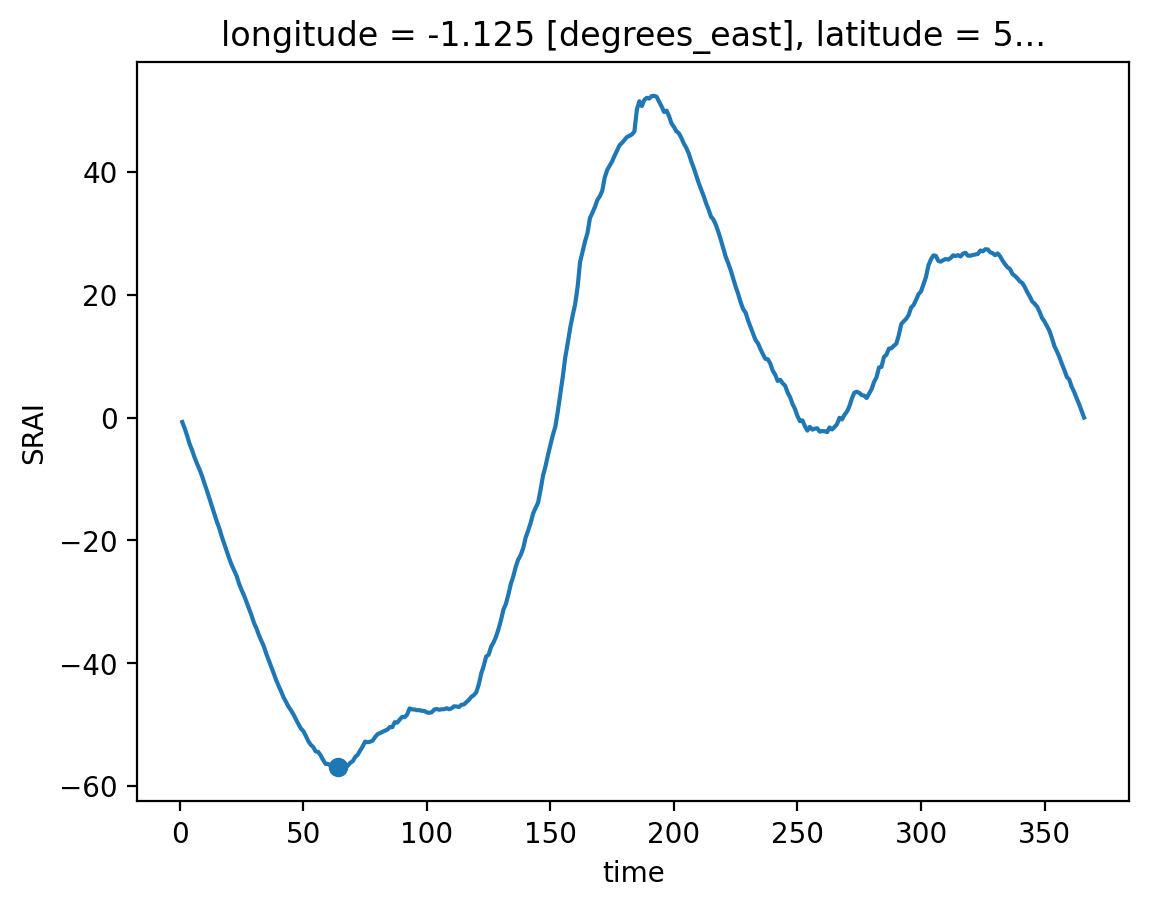

In [172]:
sr.cumulative(min_periods=1,dim='doy').sum('doy').plot()
plt.scatter(ons.values+28, sr.cumsum()[ons+28],)

In [173]:
import numpy as np
import xarray as xr
from scipy.ndimage import gaussian_filter1d


def derivative_based_onset_cessation(
    ds,
    var_name="precip",
    smooth_sigma=7,
    derivative_threshold=0.01,
    persistence_days=7,
):
    """
    Robust rainfall onset and cessation detection using:

    1. Cumulative anomaly curves
    2. First derivative (rate of change)
    3. Second derivative (acceleration/deceleration)

    This method is substantially more robust for:
    - noisy rainfall climates
    - bimodal rainfall regimes
    - weak seasonality regions
    - climate change applications

    Parameters
    ----------
    ds : xr.Dataset or xr.DataArray
        Daily rainfall data with dimensions:
        time, lat, lon

    var_name : str
        Rainfall variable name

    smooth_sigma : int or float
        Gaussian smoothing strength

    derivative_threshold : float
        Threshold for significant derivative transitions

    persistence_days : int
        Number of consecutive days required
        for onset/cessation confirmation

    Returns
    -------
    xr.Dataset
    """

    # =====================================================
    # Extract rainfall
    # =====================================================
    if isinstance(ds, xr.Dataset):
        rain = ds[var_name]
    else:
        rain = ds

    # =====================================================
    # Remove leap days
    # =====================================================
    rain = rain.sel(
        time=~(
            (rain.time.dt.month == 2)
            & (rain.time.dt.day == 29)
        )
    )

    # =====================================================
    # Create Julian day coordinate
    # =====================================================
    rain.coords["doy"] = rain.time.dt.dayofyear

    # =====================================================
    # Daily climatology
    # =====================================================
    clim_daily = rain.groupby("doy").mean("time")

    # =====================================================
    # Climatological annual mean
    # =====================================================
    clim_annual = clim_daily.mean("doy")

    # =====================================================
    # Daily anomalies
    # =====================================================
    anomaly = clim_daily - clim_annual

    # =====================================================
    # Cumulative anomaly curve
    # =====================================================
    cumulative_anomaly = anomaly.cumsum("doy")

    # =====================================================
    # Robust onset/cessation detector
    # =====================================================
    def detect_transition(cum_curve):

        cum_curve = np.asarray(cum_curve)

        # ---------------------------------------------
        # Handle missing values
        # ---------------------------------------------
        if np.all(np.isnan(cum_curve)):
            return (
                np.nan,
                np.nan,
                np.nan,
                np.nan,
                np.nan,
            )

        # ---------------------------------------------
        # Smooth cumulative curve
        # ---------------------------------------------
        smooth_curve = gaussian_filter1d(
            cum_curve,
            sigma=smooth_sigma,
            mode="nearest"
        )

        # ---------------------------------------------
        # First derivative
        # dC/dt
        # ---------------------------------------------
        first_derivative = np.gradient(smooth_curve)

        # ---------------------------------------------
        # Second derivative
        # d²C/dt²
        # ---------------------------------------------
        second_derivative = np.gradient(first_derivative)

        # ---------------------------------------------
        # Detect onset:
        #
        # Criteria:
        # 1. Positive first derivative
        # 2. Positive acceleration
        # 3. Persistence condition
        # ---------------------------------------------
        onset = np.nan

        for i in range(
            len(first_derivative) - persistence_days
        ):

            fd_window = first_derivative[
                i:i + persistence_days
            ]

            sd_window = second_derivative[
                i:i + persistence_days
            ]

            if (
                np.all(fd_window > derivative_threshold)
                and np.mean(sd_window) > 0
            ):

                onset = i + 1
                break

        # ---------------------------------------------
        # Detect cessation:
        #
        # Criteria:
        # 1. Negative first derivative
        # 2. Negative acceleration
        # 3. Persistence condition
        # ---------------------------------------------
        cessation = np.nan

        if not np.isnan(onset):

            for i in range(
                int(onset),
                len(first_derivative)
                - persistence_days
            ):

                fd_window = first_derivative[
                    i:i + persistence_days
                ]

                sd_window = second_derivative[
                    i:i + persistence_days
                ]

                if (
                    np.all(
                        fd_window
                        < -derivative_threshold
                    )
                    and np.mean(sd_window) < 0
                ):

                    cessation = i + 1
                    break

        # ---------------------------------------------
        # Compute season length
        # ---------------------------------------------
        if (
            np.isnan(onset)
            or np.isnan(cessation)
        ):

            length = np.nan

        else:

            if cessation <= onset:
                cessation += 365

            length = cessation - onset + 1

            # Reject unrealistic lengths
            if length < 20 or length > 330:
                onset = np.nan
                cessation = np.nan
                length = np.nan

        return (
            onset,
            cessation,
            length,
            first_derivative,
            second_derivative,
        )

    # =====================================================
    # Apply function across all grid points
    # =====================================================
    onset, cessation, length, fd, sd = xr.apply_ufunc(
        detect_transition,
        cumulative_anomaly,
        input_core_dims=[["doy"]],
        output_core_dims=[
            [],
            [],
            [],
            ["doy"],
            ["doy"],
        ],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[
            float,
            float,
            float,
            float,
            float,
        ],
    )

    # =====================================================
    # Build output dataset
    # =====================================================
    out = xr.Dataset({

        "daily_climatology": clim_daily,

        "annual_mean": clim_annual,

        "daily_anomaly": anomaly,

        "cumulative_anomaly": cumulative_anomaly,

        "first_derivative": fd,

        "second_derivative": sd,

        "onset_day": onset,

        "cessation_day": cessation,

        "season_length": length,
    })

    # =====================================================
    # Metadata
    # =====================================================
    out["first_derivative"].attrs = {
        "description":
        "Rate of change of cumulative anomaly"
    }

    out["second_derivative"].attrs = {
        "description":
        "Acceleration/deceleration of cumulative anomaly"
    }

    out["onset_day"].attrs = {
        "description":
        "Rainfall onset Julian day"
    }

    out["cessation_day"].attrs = {
        "description":
        "Rainfall cessation Julian day"
    }

    out["season_length"].attrs = {
        "description":
        "Rainy season duration"
    }

    return out

In [226]:
# Run analysis
results2 = derivative_based_onset_cessation(
    precip_chirps_2,
    var_name="precip",
    # window=28
)

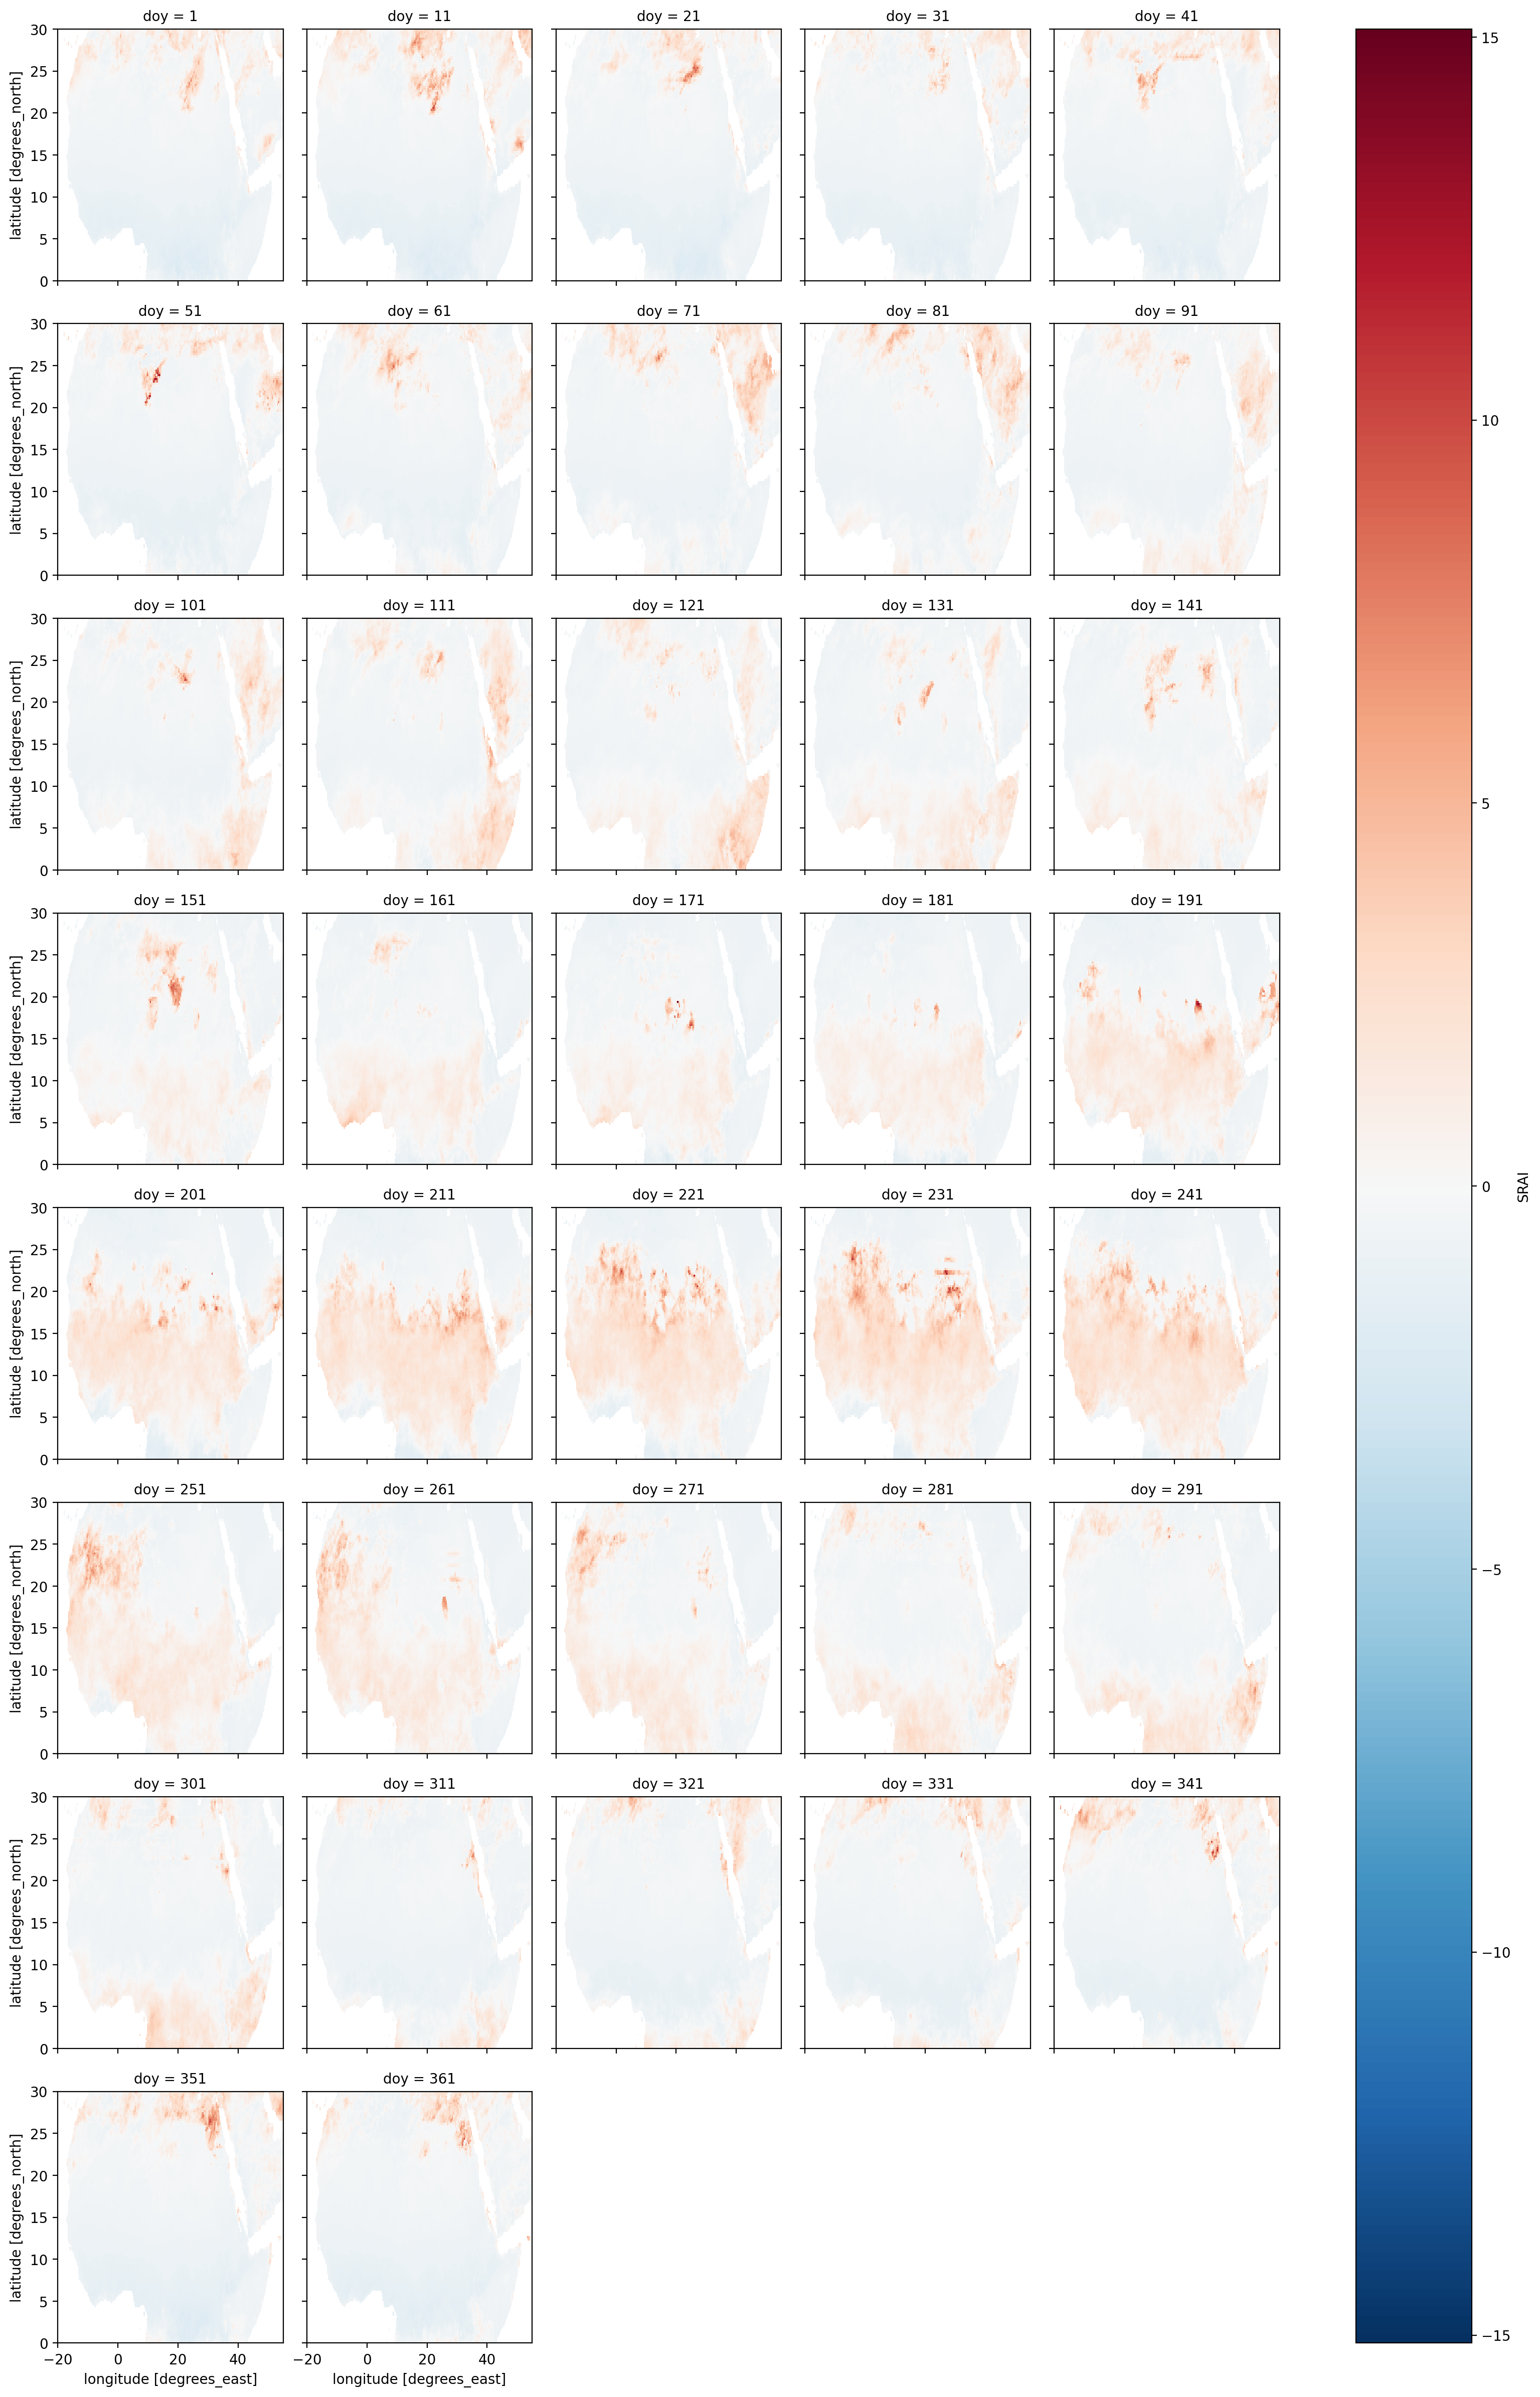

In [188]:
results['SRAI'][::10].plot(col='doy',col_wrap=5)

In [238]:
rs = results2

In [239]:
rs['doy'] = rs['doy']-183


In [240]:

ons = rs.sel(longitude=-1.25,latitude=5.25,method='nearest')['onset_day']
ces = rs.sel(longitude=-1.25,latitude=5.25,method='nearest')['cessation_day']
can = rs.sel(longitude=-1.25,latitude=5.25,method='nearest')['cumulative_anomaly']
# sr = results2.sel(longitude=-1.25,latitude=5.25,method='nearest')['SRAI']
# ons_ix = list(sr).index(ons)

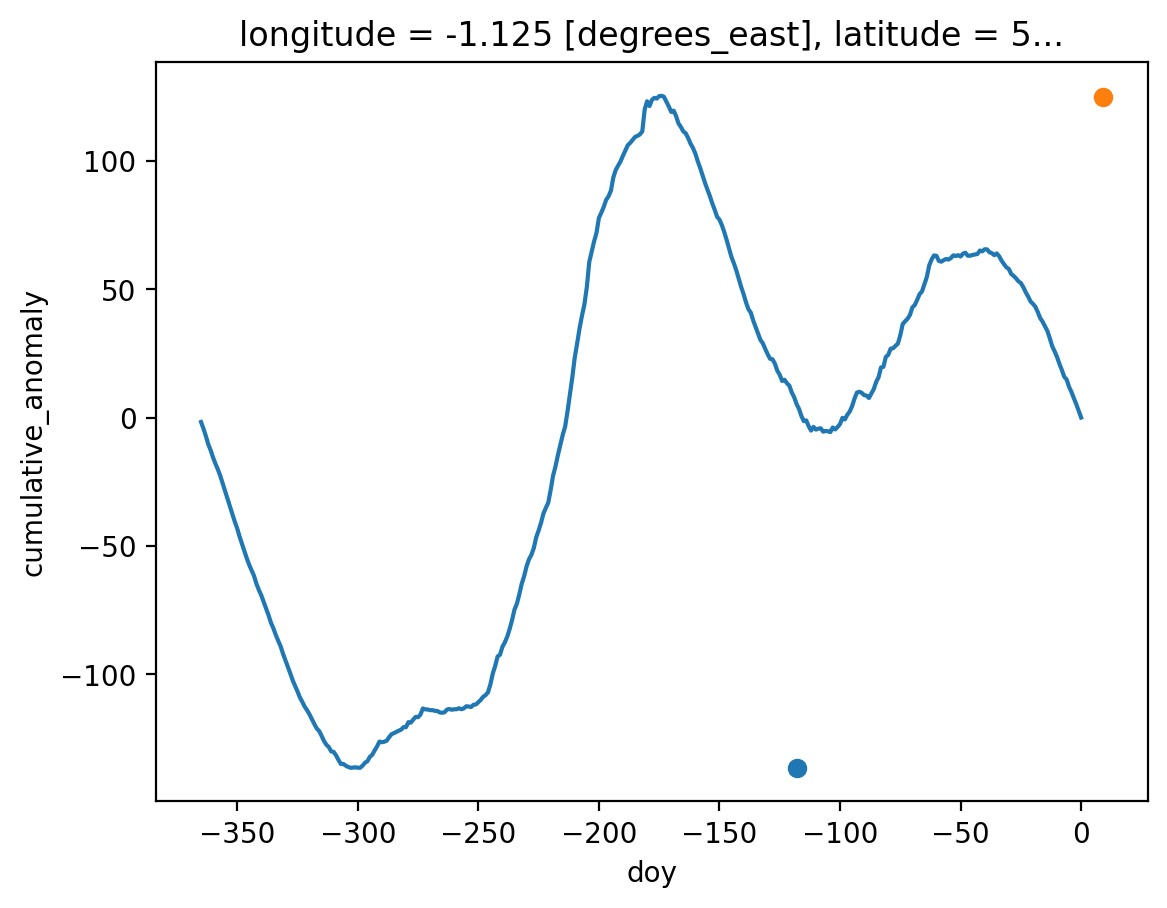

In [241]:
can.plot()
plt.scatter(ons.values-183, can[int(ons.values)].values,)
plt.scatter(ces.values-183, can[int(ces.values)].values,)
# plt.set_xlim(-

In [206]:
366/2

183.0